Generating 1000 simulations...
  Simulation 50...
  Simulation 100...
  Simulation 150...
  Simulation 200...
  Simulation 250...
  Simulation 300...
  Simulation 350...
  Simulation 400...
  Simulation 450...
  Simulation 500...
  Simulation 550...
  Simulation 600...
  Simulation 650...
  Simulation 700...
  Simulation 750...
  Simulation 800...
  Simulation 850...
  Simulation 900...
  Simulation 950...
  Simulation 1000...

Training...
Epoch 0, Loss: 8.8263
Epoch 20, Loss: 2.5032
Epoch 40, Loss: 0.5535
Epoch 60, Loss: 0.0766
Epoch 80, Loss: 0.0314
Epoch 100, Loss: 0.0251


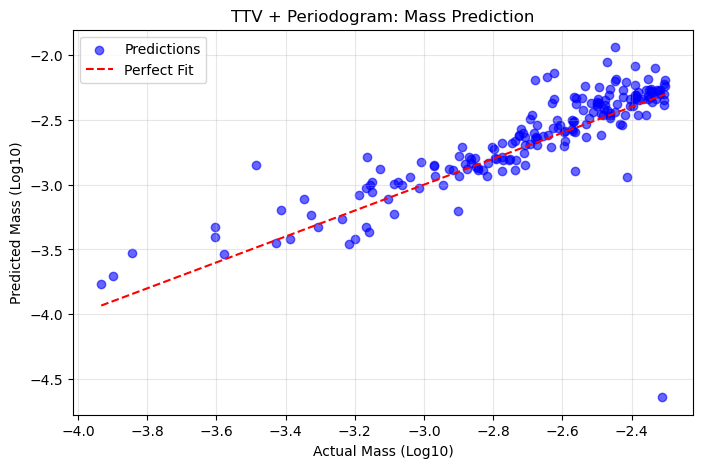


Amplitude-to-Mass Correlation: 0.1949


In [1]:
import numpy as np
import rebound
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from astropy.timeseries import LombScargle
from scipy.stats import pearsonr

#-----------------------------------------------------------------------------
# Utility Functions
#-----------------------------------------------------------------------------

def detect_transits(sim, integration_time, dt, max_transits, planet_index):
    transit_times = []
    star = sim.particles[0]
    planet = sim.particles[planet_index]
    prev_y = planet.y - star.y
    
    time = 0
    while time < integration_time and len(transit_times) < max_transits:
        sim.integrate(sim.t + dt)
        time = sim.t
        curr_y = planet.y - star.y
        if prev_y * curr_y < 0 and (planet.x - star.x) > 0:
            weight = -prev_y / (curr_y - prev_y)
            precise_time = (time - dt) + (weight * dt)
            transit_times.append(precise_time)
        prev_y = curr_y
    return np.array(transit_times)

def detrend_ttv(ttv_data):
    N = len(ttv_data)
    transit_numbers = np.arange(N)
    P = np.polyfit(transit_numbers, ttv_data, 1)
    return ttv_data - (P[0] * transit_numbers + P[1])

#-----------------------------------------------------------------------------
# PHASE 1: GENERATE DATA WITH PERIODOGRAM
#-----------------------------------------------------------------------------

def generate_simulation_data(num_simulations, max_transits, dt):
    print(f"Generating {num_simulations} simulations...")
    all_features = []
    all_masses = []
    
    # Use strong resonances to ensure a learnable signal
    resonances = [1.5, 2.0] 
    
    for i in range(num_simulations):
        if (i + 1) % 50 == 0: print(f"  Simulation {i+1}...")
        
        try:
            # Randomize Planet B
            m_b = np.random.uniform(1e-5, 1e-4)
            P_b = np.random.uniform(1.0, 5.0)
            e_b = np.random.uniform(0.0, 0.02)
            
            # Randomize Planet C (The Perturber)
            ratio = np.random.choice(resonances) + np.random.uniform(-0.02, 0.02)
            m_c = np.random.uniform(1e-4, 5e-3) 
            P_c = P_b * ratio
            e_c = np.random.uniform(0.0, 0.05)

            # Unperturbed Simulation
            sim_u = rebound.Simulation()
            sim_u.integrator = "whfast"; sim_u.dt = dt
            sim_u.add(m=1.0); sim_u.add(m=m_b, P=P_b, e=e_b)
            transits_u = detect_transits(sim_u, P_b*(max_transits+5), dt, max_transits, 1)

            # Perturbed Simulation
            sim_p = rebound.Simulation()
            sim_p.integrator = "whfast"; sim_p.dt = dt
            sim_p.add(m=1.0); sim_p.add(m=m_b, P=P_b, e=e_b)
            sim_p.add(m=m_c, P=P_c, e=e_c)
            sim_p.move_to_com()
            transits_p = detect_transits(sim_p, P_b*(max_transits+5), dt, max_transits, 1)

            if len(transits_u) >= max_transits and len(transits_p) >= max_transits:
                ttv_vec = detrend_ttv(transits_p[:max_transits] - transits_u[:max_transits])
                
                # --- PERIODOGRAM LOGIC ---
                # Search for cycles between 3 transits and 50 transits
                freqs = np.linspace(1/50, 1/3, 40)
                power = LombScargle(np.arange(max_transits), ttv_vec).power(freqs)
                
                # Feature Construction: [Amplitude, Power Spectrum, Phys Params]
                amp = np.std(ttv_vec)
                phys = [P_b, ratio, e_b]
                
                sample = np.hstack(([amp], power, phys))
                all_features.append(sample)
                all_masses.append(m_c)

        except Exception: continue

    return np.array(all_features), np.array(all_masses)

#-----------------------------------------------------------------------------
# PHASE 2: IMPROVED MODEL
#-----------------------------------------------------------------------------

class MassPredictor(nn.Module):
    def __init__(self, input_size):
        super(MassPredictor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.1),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.network(x)

#-----------------------------------------------------------------------------
# PHASE 3: TRAINING AND EVALUATION
#-----------------------------------------------------------------------------

if __name__ == "__main__":
    X_raw, y_raw = generate_simulation_data(1000, 100, 0.01)
    
    # Log Scaling for Mass (converts tiny decimals to manageable numbers like -1 to -4)
    y_log = np.log10(y_raw)
    
    scaler_X = StandardScaler()
    X_scaled = scaler_X.fit_transform(X_raw)
    
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_log, test_size=0.2)
    
    model = MassPredictor(X_train.shape[1])
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    
    print("\nTraining...")
    for epoch in range(101):
        model.train()
        optimizer.zero_grad()
        pred = model(torch.tensor(X_train, dtype=torch.float32)).flatten()
        loss = criterion(pred, torch.tensor(y_train, dtype=torch.float32))
        loss.backward()
        optimizer.step()
        if epoch % 20 == 0: print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

    # Results
    model.eval()
    with torch.no_grad():
        test_preds = model(torch.tensor(X_test, dtype=torch.float32)).numpy().flatten()
    
    # Plotting
    plt.figure(figsize=(8, 5))
    plt.scatter(y_test, test_preds, alpha=0.6, color='blue', label='Predictions')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Fit')
    plt.xlabel("Actual Mass (Log10)")
    plt.ylabel("Predicted Mass (Log10)")
    plt.title("TTV + Periodogram: Mass Prediction")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    corr, _ = pearsonr(X_raw[:, 0], y_raw)
    print(f"\nAmplitude-to-Mass Correlation: {corr:.4f}")